# EDA 06: CRISPR Gene Effect, Dependency, and Common Essentials

## Purpose

CRISPR can be used like molecular scissors to disable one gene at a time. If a cell line grows much worse after gene B is disabled, that cell line probably depends on gene B. This is the closest table we have to an experimental answer about which genes a cell needs.

`GeneEffect` describes how strongly growth changed after knockout. More negative values usually mean a stronger loss of fitness. `GeneDependency` expresses the same broad question on a probability-like scale, where larger values mean stronger evidence of dependency. Common-essential genes are needed by many cell lines and can produce strong but non-selective results.

## Questions

1. Do gene-effect and dependency matrices cover the same models and genes?
2. Which genes are broadly essential and which are selective to a smaller group?
3. How do common essentials differ from other genes?
4. Does dependency differ by cancer lineage?
5. Do example gene pairs remain codependent after allowing for lineage?

**Important:** a strong dependency on gene B does not by itself show that gene A is related to it. Codependency and conditional dependency require comparisons across many models with exact denominators.

## Decisions inherited from earlier EDA

- Join models only with `model_id` and retain screen/library QC as visible confidence context.
- Use released CRISPR matrices as the primary dependency measurements.
- Compare lineages and report the number of models used.
- Treat QC, growth rate, Cas activity, and numerical outliers as review context rather than biological pair evidence.
- Compare library-related QC within library; do not mix Avana, KY, and Humagne-CD scales blindly.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'

PATHS = {
    'master': DATA / 'architecture' / 'model_master.csv',
    'effect': DATA / 'raw' / 'CRISPRGeneEffect.csv',
    'dependency': DATA / 'raw' / 'CRISPRGeneDependency.csv',
    'essentials': DATA / 'raw' / 'CRISPRInferredCommonEssentials.csv',
}
master = pd.read_csv(PATHS['master'], low_memory=False)
effect_columns = pd.read_csv(PATHS['effect'], nrows=0).columns.tolist()
dependency_columns = pd.read_csv(PATHS['dependency'], nrows=0).columns.tolist()
common_essentials = pd.read_csv(PATHS['essentials'])
print(f'Gene-effect features: {len(effect_columns)-1:,}')
print(f'Dependency features: {len(dependency_columns)-1:,}')
print(f'Common-essential genes: {len(common_essentials):,}')

Gene-effect features: 17,916
Dependency features: 17,916
Common-essential genes: 1,523


## Column dictionary

| Table / column | Plain-language meaning | Use in this project |
| --- | --- | --- |
| `CRISPRGeneEffect.Unnamed: 0` | DepMap `model_id`. | Only automatic model join key. |
| `CRISPRGeneEffect.<GENE> (Entrez ID)` | Growth effect after disabling that gene. More negative usually means more harm. | Main quantitative knockout evidence. |
| `CRISPRGeneDependency.Unnamed: 0` | DepMap `model_id`. | Aligns dependency with gene effect. |
| `CRISPRGeneDependency.<GENE> (Entrez ID)` | Probability-like dependency evidence; larger means stronger dependency. | Easier-to-explain second view of knockout evidence. |
| `CRISPRInferredCommonEssentials.Essentials` | Gene inferred to be essential in many models. | Guardrail against calling generic survival genes selective pair partners. |

The number in brackets is an Entrez gene identifier. It helps distinguish genes with similar names.

## 1. Matrix alignment and denominator

Both matrices should describe the same model-gene grid. We verify model IDs and columns before comparing any values.

In [2]:
effect_ids = pd.read_csv(PATHS['effect'], usecols=['Unnamed: 0'])['Unnamed: 0']
dependency_ids = pd.read_csv(PATHS['dependency'], usecols=['Unnamed: 0'])['Unnamed: 0']
eligible_ids = set(master.loc[master['eligible_codependency_route'].eq(1), 'model_id'])

alignment = pd.DataFrame([{
    'effect_models': effect_ids.nunique(),
    'dependency_models': dependency_ids.nunique(),
    'same_model_order': effect_ids.equals(dependency_ids),
    'same_gene_columns': effect_columns == dependency_columns,
    'effect_models_outside_codependency_route': len(set(effect_ids) - eligible_ids),
    'duplicate_effect_model_ids': int(effect_ids.duplicated().sum()),
}])
display(alignment)
assert effect_ids.equals(dependency_ids)
assert effect_columns == dependency_columns
assert not (set(effect_ids) - eligible_ids)

,effect_models,dependency_models,same_model_order,same_gene_columns,effect_models_outside_codependency_route,duplicate_effect_model_ids
0,1178,1178,True,True,0,0


### What this means for the project

Each CRISPR row represents one cell line, and both matrices describe the same experiments. If a model is absent, we do not call it non-dependent; we leave the result unknown and exclude it from that denominator.

## 2. Full-matrix selectivity audit

A broadly essential gene harms almost every model when disabled. A selective dependency harms only a subset, which is usually more useful for explaining why one cancer context differs from another.

In [3]:
def summarise_crispr_matrix(path, value_name, strong_rule, chunksize=64):
    columns = pd.read_csv(path, nrows=0).columns.tolist()
    n_features = len(columns) - 1
    sums = np.zeros(n_features)
    sums_sq = np.zeros(n_features)
    counts = np.zeros(n_features, dtype=np.int64)
    strong = np.zeros(n_features, dtype=np.int64)
    model_rows = []
    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
        values = chunk.iloc[:, 1:].to_numpy(dtype=np.float64, copy=False)
        valid = np.isfinite(values)
        sums += np.nansum(values, axis=0)
        sums_sq += np.nansum(values * values, axis=0)
        counts += valid.sum(axis=0)
        strong += strong_rule(values).sum(axis=0)
        model_rows.append(pd.DataFrame({
            'model_id': chunk.iloc[:, 0].astype(str),
            f'mean_{value_name}': np.nanmean(values, axis=1),
            f'strong_{value_name}_gene_pct': 100 * strong_rule(values).sum(axis=1) / valid.sum(axis=1),
        }))
    means = sums / counts
    summary = pd.DataFrame({
        'feature': columns[1:], 'mean': means,
        'sd': np.sqrt(np.maximum(sums_sq / counts - means**2, 0)),
        'strong_pct': 100 * strong / counts,
    })
    summary['gene'] = summary['feature'].str.replace(r' \(\d+\)$', '', regex=True)
    return pd.concat(model_rows, ignore_index=True), summary

effect_model_summary, effect_gene_summary = summarise_crispr_matrix(PATHS['effect'], 'effect', lambda x: x <= -0.5)
dependency_model_summary, dependency_gene_summary = summarise_crispr_matrix(PATHS['dependency'], 'dependency', lambda x: x >= 0.5)
essential_names = set(common_essentials['Essentials'].str.replace(r' \(\d+\)$', '', regex=True))
effect_gene_summary['is_common_essential'] = effect_gene_summary['gene'].isin(essential_names)
dependency_gene_summary['is_common_essential'] = dependency_gene_summary['gene'].isin(essential_names)

display(effect_gene_summary[['mean', 'sd', 'strong_pct']].describe().T)
display(dependency_gene_summary[['mean', 'sd', 'strong_pct']].describe().T)
display(Markdown('#### Most broadly strong dependency genes'))
display(dependency_gene_summary.nlargest(25, 'strong_pct'))
display(Markdown('#### Most variable dependency genes'))
display(dependency_gene_summary.nlargest(25, 'sd'))

,count,mean,std,min,25%,50%,75%,max
mean,17916.0,-0.143148,0.380974,-4.249576,-0.139804,-0.035528,0.035100,0.474211
sd,17916.0,0.142842,0.069369,0.065891,0.104555,0.118178,0.145902,0.830395
strong_pct,17916.0,9.862891,25.941315,0.000000,0.000000,0.169779,1.273345,100.000000


,count,mean,std,min,25%,50%,75%,max
mean,17916.0,0.147067,0.247081,0.000717,0.025524,0.047640,0.112487,1.000000
sd,17916.0,0.082250,0.074563,0.000001,0.032301,0.055044,0.102176,0.402594
strong_pct,17916.0,10.656099,26.604546,0.000000,0.000000,0.169779,1.867572,100.000000


#### Most broadly strong dependency genes

,feature,mean,sd,strong_pct,gene,is_common_essential
21,AARS1 (16),0.998666,0.010565,100.0,AARS1,True
66,ABCE1 (6059),0.999762,0.002363,100.0,ABCE1,True
447,AHCTF1 (25909),0.980608,0.031926,100.0,AHCTF1,True
594,ALYREF (10189),0.984699,0.031693,100.0,ALYREF,True
637,ANAPC5 (51433),0.989371,0.023406,100.0,ANAPC5,True
668,ANKLE2 (23141),0.998711,0.011192,100.0,ANKLE2,True
1290,AURKB (9212),0.999339,0.010275,100.0,AURKB,True
1369,BANF1 (8815),0.998845,0.016604,100.0,BANF1,True
1601,BRF2 (55290),0.996446,0.014363,100.0,BRF2,True
1669,BUD31 (8896),0.999444,0.003916,100.0,BUD31,True


#### Most variable dependency genes

,feature,mean,sd,strong_pct,gene,is_common_essential
5065,FAM50A (9130),0.469203,0.402594,43.039049,FAM50A,False
2319,CCND1 (595),0.670369,0.393551,66.553480,CCND1,False
16463,TYMS (7298),0.530526,0.393546,49.151104,TYMS,False
14353,SNAP23 (8773),0.609140,0.387048,60.865874,SNAP23,False
2550,CDK6 (1021),0.544759,0.384822,55.263158,CDK6,False
13458,SDHB (6390),0.464855,0.384684,44.991511,SDHB,False
4489,EFR3A (23167),0.433457,0.384176,41.001698,EFR3A,False
5254,FERMT2 (10979),0.527865,0.382352,50.254669,FERMT2,False
12817,RIC1 (57589),0.530570,0.381180,52.292020,RIC1,False
14446,SOD2 (6648),0.617438,0.380794,62.308998,SOD2,False


### What this means for the project

A gene that every cell line needs may have a very strong CRISPR signal but tells us little about a special relationship with gene A. A variable gene is more selective, but variability alone is not proof of a useful pair. It becomes meaningful when mutation, copy number, lineage, or another clear context explains who depends on it.

## 3. Common-essential guardrail

Common essentials often control basic jobs such as making proteins or copying DNA. Knocking them out harms nearly every cell, so they can dominate rankings unless we label them explicitly.

,genes,median_dependency,median_models_strong_pct,median_sd
is_common_essential,,,,
False,16393,0.042837,0.169779,0.053419
True,1523,0.943200,98.471986,0.109348


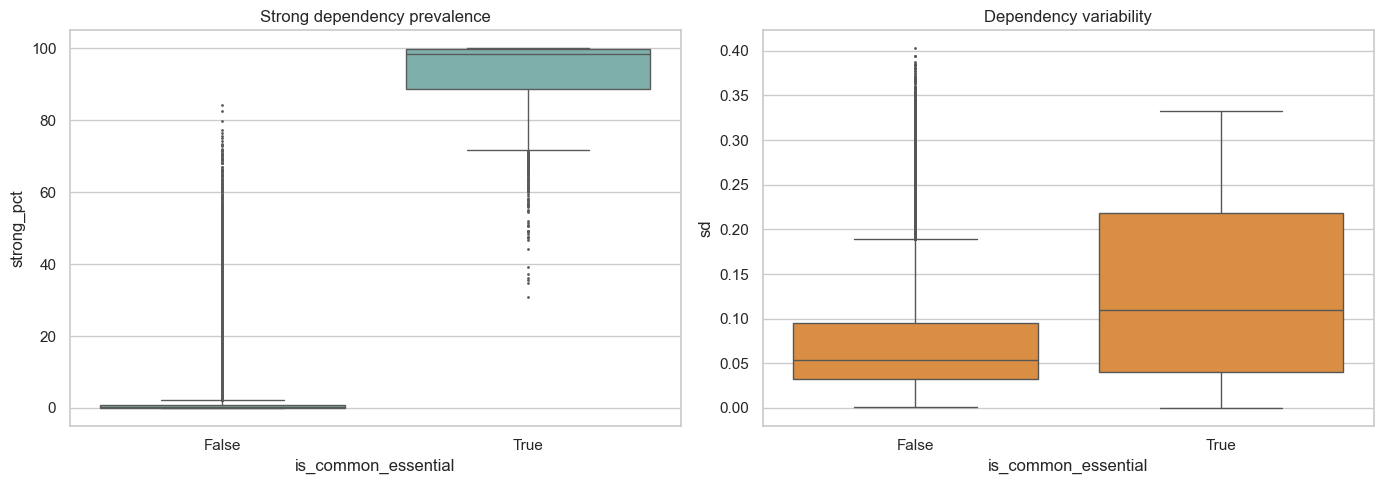

In [4]:
essential_comparison = dependency_gene_summary.groupby('is_common_essential').agg(
    genes=('gene', 'size'), median_dependency=('mean', 'median'),
    median_models_strong_pct=('strong_pct', 'median'), median_sd=('sd', 'median'),
)
display(essential_comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=dependency_gene_summary, x='is_common_essential', y='strong_pct', ax=axes[0], color='#76B7B2', fliersize=1)
axes[0].set_title('Strong dependency prevalence')
sns.boxplot(data=dependency_gene_summary, x='is_common_essential', y='sd', ax=axes[1], color='#F28E2B', fliersize=1)
axes[1].set_title('Dependency variability')
plt.tight_layout(); plt.show()

### What this means for the project

Common-essential status is a warning label, not an automatic ban. If gene B is essential in nearly every model, the dashboard should say so plainly. A pair result is more interesting when dependency on B is selective and changes with gene-A status.

## 4. Example genes, lineage, and codependency

Codependency means two genes have similar knockout patterns across cell lines. This can happen because they work in the same process, but also because both are linked to the same cancer lineage.

In [5]:
PANEL = ['BRCA1', 'BRCA2', 'ARID1A', 'EZH2', 'EML4', 'ALK', 'EGFR', 'KRAS', 'TP53', 'MYC', 'CDK4', 'MDM2']
def feature_for_gene(columns, gene):
    matches = [c for c in columns if c.startswith(f'{gene} (')]
    return matches[0] if len(matches) == 1 else None

panel_columns = {gene: feature_for_gene(effect_columns, gene) for gene in PANEL}
panel_columns = {gene: col for gene, col in panel_columns.items() if col}
effect_panel = pd.read_csv(PATHS['effect'], usecols=['Unnamed: 0', *panel_columns.values()]).rename(columns={'Unnamed: 0': 'model_id', **{v: k for k, v in panel_columns.items()}})
dependency_panel = pd.read_csv(PATHS['dependency'], usecols=['Unnamed: 0', *panel_columns.values()]).rename(columns={'Unnamed: 0': 'model_id', **{v: k for k, v in panel_columns.items()}})
panel = dependency_panel.merge(master[['model_id', 'oncotree_lineage']], on='model_id', how='left', validate='one_to_one')

lineage_medians = panel.groupby('oncotree_lineage')[list(panel_columns)].median()
display(lineage_medians.round(2))

PAIRS = [('BRCA1', 'BRCA2'), ('ARID1A', 'EZH2'), ('CDK4', 'MDM2'), ('EGFR', 'KRAS')]
rows = []
for a, b in PAIRS:
    selected = panel[['oncotree_lineage', a, b]].dropna()
    usable = selected.groupby('oncotree_lineage')[a].transform('size').ge(15)
    within = selected.loc[usable]
    residuals = within[[a, b]] - within.groupby('oncotree_lineage')[[a, b]].transform('median')
    rows.append({
        'pair': f'{a}-{b}', 'models': len(selected),
        'all_model_spearman': selected[a].corr(selected[b], method='spearman'),
        'lineage_adjusted_models': len(within),
        'lineage_adjusted_spearman': residuals[a].corr(residuals[b], method='spearman'),
    })
display(pd.DataFrame(rows).round(3))

,BRCA1,BRCA2,ARID1A,EZH2,EML4,ALK,EGFR,KRAS,TP53,MYC,CDK4,MDM2
oncotree_lineage,,,,,,,,,,,,
Adrenal Gland,0.11,0.02,0.03,0.01,0.12,0.02,0.05,0.19,0.03,1.00,0.65,0.02
Ampulla of Vater,0.30,0.68,0.28,0.17,0.10,0.03,0.92,0.88,0.00,1.00,0.81,0.47
Biliary Tract,0.37,0.54,0.11,0.02,0.06,0.05,0.66,0.62,0.00,1.00,0.87,0.44
Bladder/Urinary Tract,0.57,0.60,0.13,0.02,0.06,0.04,0.24,0.46,0.00,1.00,0.67,0.34
Bone,0.50,0.46,0.06,0.02,0.05,0.03,0.07,0.38,0.00,1.00,0.97,0.33
Bowel,0.35,0.25,0.12,0.05,0.08,0.03,0.31,0.97,0.01,1.00,0.87,0.40
Breast,0.54,0.60,0.21,0.05,0.05,0.04,0.12,0.34,0.01,1.00,0.93,0.39
CNS/Brain,0.59,0.52,0.20,0.02,0.06,0.04,0.05,0.23,0.00,1.00,0.72,0.41
Cervix,0.41,0.74,0.13,0.03,0.06,0.04,0.47,0.21,0.00,1.00,0.62,0.38


,pair,models,all_model_spearman,lineage_adjusted_models,lineage_adjusted_spearman
0,BRCA1-BRCA2,1178,0.331,1143,0.326
1,ARID1A-EZH2,1178,0.061,1143,0.025
2,CDK4-MDM2,1178,0.210,1143,0.168
3,EGFR-KRAS,1178,0.164,1143,0.116


### What this means for the project

If two genes have similar dependency values across all models but the relationship weakens after lineage adjustment, cancer type probably explains part of the pattern. We will carry both correlations, sample sizes, and common-essential labels rather than presenting one unexplained number.

## Decisions carried into absolute copy-number EDA

- Use gene effect as the main continuous knockout result and dependency probability as a second, explainable view.
- Label common-essential genes and dependency selectivity; do not rank broad essentials as special partners without context.
- Report codependency both overall and after lineage adjustment, with exact model counts.
- Carry CRISPR QC, efficacy, growth, and numerical review flags into later sensitivity analysis.
- For conditional dependency, define gene-A alteration using mutation and copy number only where both the alteration assay and CRISPR result are available.
- The copy-number notebook must therefore report its overlap with the 1,178 CRISPR models and must not call missing copy number normal.